In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cleaned_data=pd.read_csv("Cleaned_data_for_eda.csv")
cleaned_data

,Unnamed: 0,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,0,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,1,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,2,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,3,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,4,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,7038,34.341737,-116.539416,Female,No,No,No,72,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.40,0
7028,7039,34.667815,-117.536183,Male,No,Yes,Yes,24,Yes,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7029,7040,34.559882,-115.637164,Female,No,Yes,Yes,72,Yes,Yes,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7030,7041,34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0


In [4]:
cleaned_data.shape

(7032, 23)

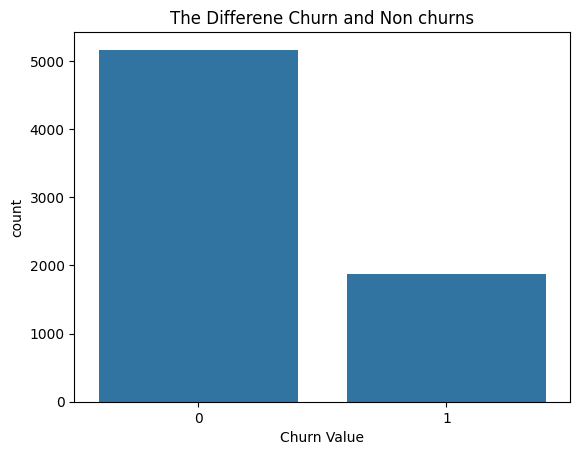

In [3]:
sns.countplot(data=cleaned_data,x="Churn Value")
plt.title("The Differene Churn and Non churns")
plt.show()

In [4]:
cleaned_data["Churn Value"].value_counts(normalize=True)*100

Churn Value
0    73.421502
1    26.578498
Name: proportion, dtype: float64

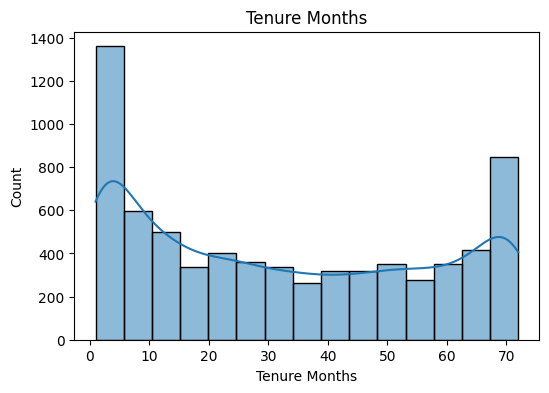

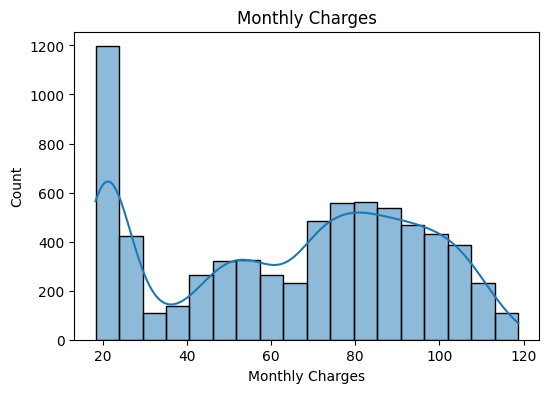

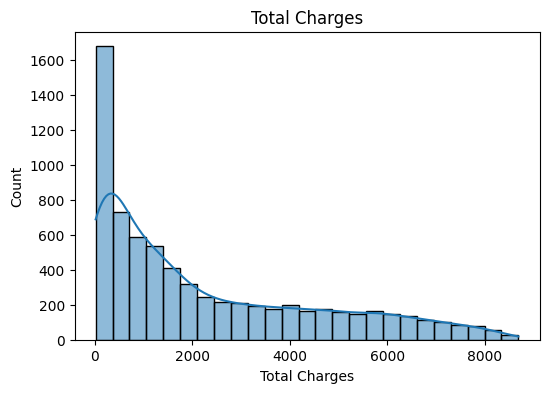

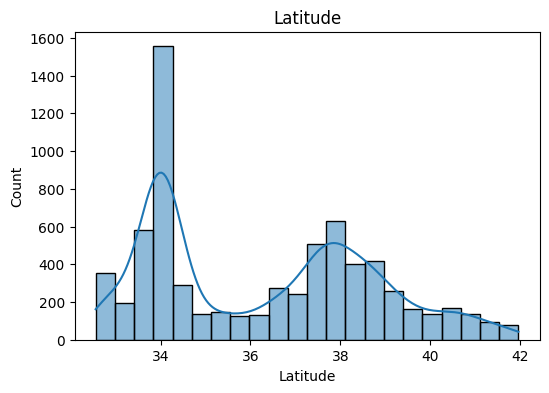

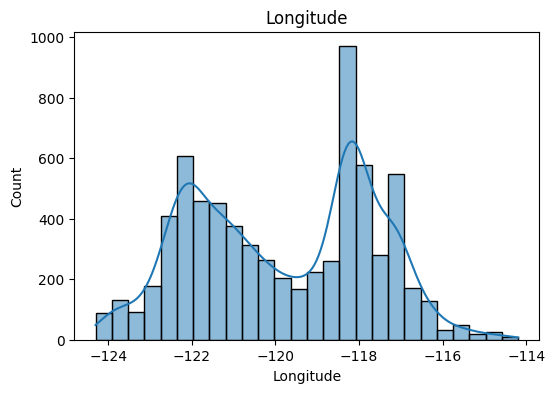

In [5]:
nums_cols=[
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Latitude",
    "Longitude"
]

for col in nums_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(cleaned_data[col],kde=True)
    plt.title(col)
    plt.show()

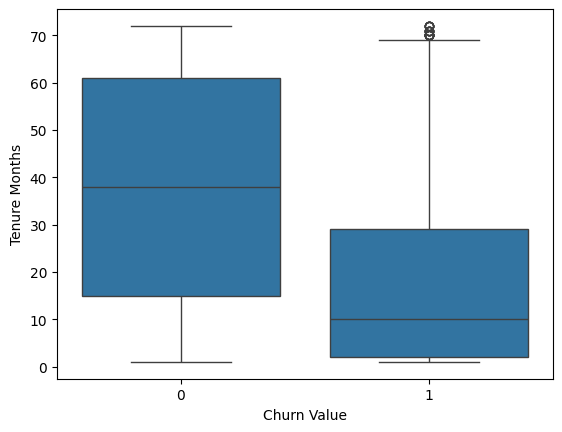

In [11]:
sns.boxplot(data=cleaned_data,x="Churn Value",y="Tenure Months")
plt.show()

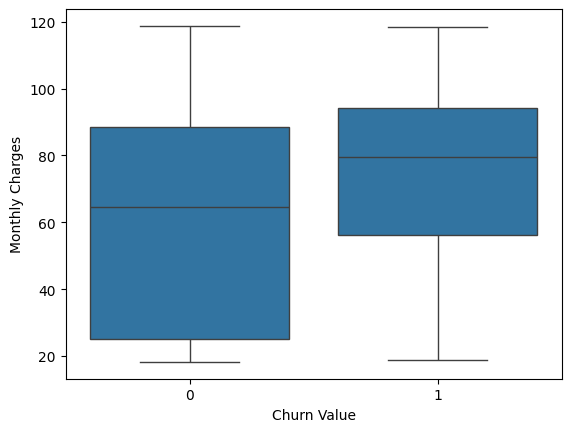

In [13]:
sns.boxplot(data=cleaned_data,x="Churn Value",y="Monthly Charges")
plt.show()

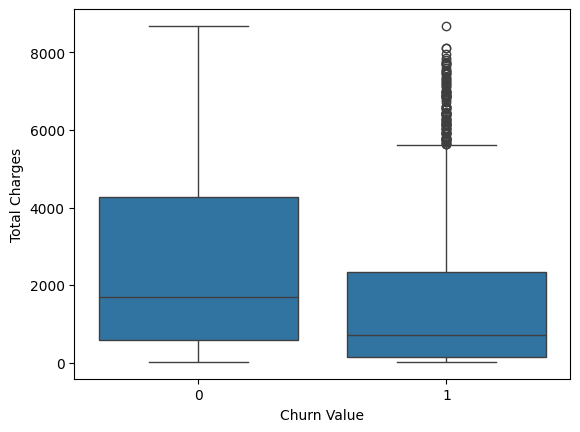

In [14]:
sns.boxplot(data=cleaned_data,x="Churn Value",y="Total Charges")
plt.show()

In [7]:
cat_col=cleaned_data.select_dtypes(include="object").columns
cat_col

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method'],
      dtype='object')

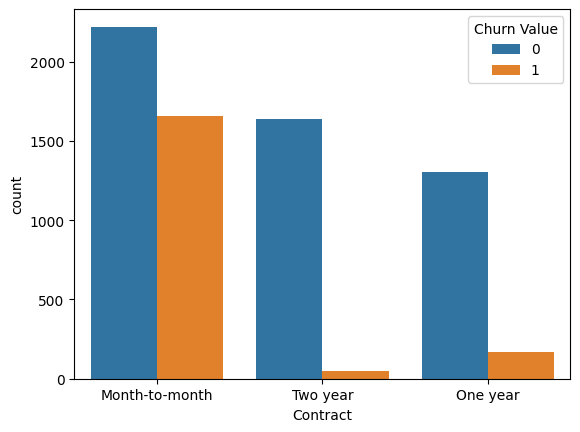

In [ ]:
pd.crosstab(cleaned_data["Contract"],cleaned_data["Churn Value"],normalize=True)
sns.countplot(x="Contract",hue="Churn Value",data=cleaned_data)
plt.show()

#month to month are more likely to churn

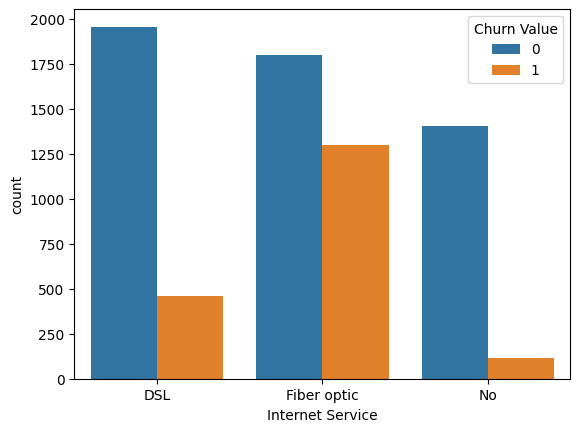

In [ ]:
sns.countplot(x="Internet Service",hue="Churn Value",data=cleaned_data)
plt.show()

#fibre optic internet service users more likely to churn

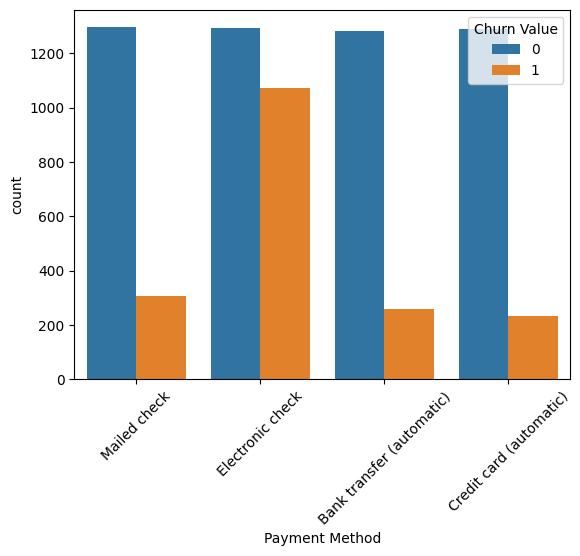

In [11]:
sns.countplot(x="Payment Method",hue="Churn Value",data=cleaned_data)
plt.xticks(rotation=45)
plt.show()

#electronic check payer where more likely to churn

In [ ]:
from sklearn.preprocessing import LabelEncoder

temp=cleaned_data.copy()


for col in temp.select_dtypes(include="object"):
    temp[col]=LabelEncoder().fit_transform(temp[col])


In [16]:
corr=temp.corr()

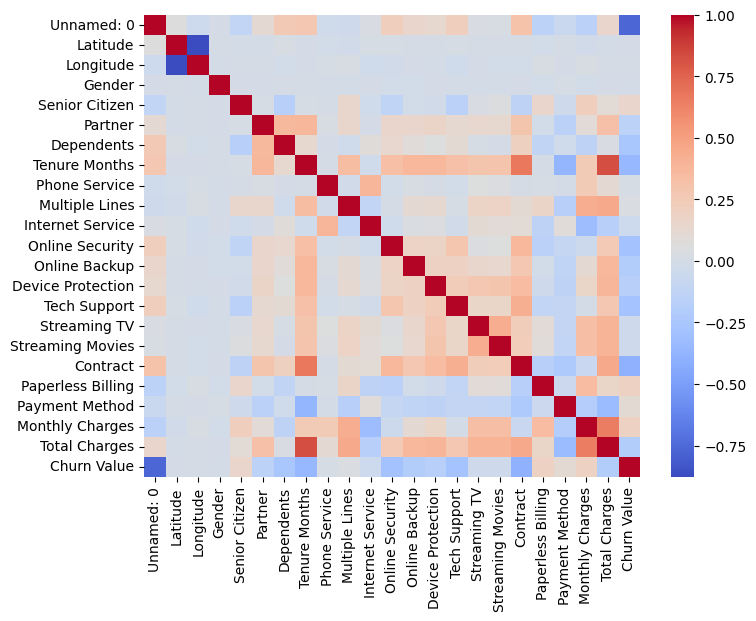

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,cmap="coolwarm")
plt.show()

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = temp.drop('Churn Value', axis=1)
y = temp['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf.feature_importances_
})

importance.sort_values(by="Importance",ascending=False).head(10)

,Feature,Importance
0,Unnamed: 0,0.723901
17,Contract,0.042769
7,Tenure Months,0.040351
11,Online Security,0.026080
20,Monthly Charges,0.024021
21,Total Charges,0.023642
14,Tech Support,0.017629
12,Online Backup,0.014398
2,Longitude,0.013479
1,Latitude,0.013269
